# Lab 1 — The Model Zoo: What IS a Prediction?

---

> **Lessons covered**: 01 Narrow vs General AI · 02 Predictive Systems · 03 Discriminative Models
> **Metric introduced**: Accuracy (and why it lies)

---

## Learning Goal

We **start with a prediction from an LLM**, then compare to classical models. Five completely different algorithms — one task, one output format.
By the end of this lab you will understand:

1. What an LLM returns for a simple approve/deny question (and why that matters)
2. Why loan approval is a **narrow AI** task: fixed input space, fixed output space (`approve` / `deny`)
3. How four different **discriminative models** each find a different boundary between approved and denied
4. Why **accuracy** is the intuitive first metric — and exactly why it is dangerous to stop there

---

> **Tutor note**: The most important moment is **Section 7 — The Accuracy Trap**.
> Students should feel genuinely tricked when a zero-intelligence model scores 65% accuracy.
> Do **not** spoil this — let the result land on its own.

In [16]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from openai import OpenAI

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('All imports OK')

All imports OK


---
## Section 1 — Load & Explore the Dataset

Before building any model we need to understand the data.
At this point we only use **four features** — the minimum viable prediction set.

| Feature | Type | Meaning |
|---|---|---|
| `credit_score` | int 300–850 | Borrower credit history score |
| `annual_income` | float (€) | Verified yearly income |
| `loan_amount` | float (€) | Amount requested |
| `num_defaults` | int 0–5 | Past payment defaults |
| **`approved`** | **0 / 1** | **Target label — what we predict** |

> **Why narrow AI?**  
> The input is a fixed set of structured fields. The output is always 0 or 1.  
> Nothing else. The model cannot write text, reason about context, or handle  
> any task outside this scope. That is the definition of **narrow AI**.

In [17]:
DATA_PATH = Path('../data/loan_applications.csv')
df = pd.read_csv(DATA_PATH)

# Lab 1 uses only the first four features
FEATURES = ['credit_score', 'annual_income', 'loan_amount', 'num_defaults']
TARGET   = 'approved'

print(f'Dataset: {df.shape[0]} applicants, {df.shape[1]} total columns')
print(f'Lab 1 uses : {FEATURES}')
print()
df[FEATURES + [TARGET]].describe().round(2)

Dataset: 1000 applicants, 13 total columns
Lab 1 uses : ['credit_score', 'annual_income', 'loan_amount', 'num_defaults']



,credit_score,annual_income,loan_amount,num_defaults,approved
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,650.76,59355.93,17858.13,0.33,0.65
std,86.87,27664.37,11386.18,0.57,0.48
min,358.00,18000.00,3000.00,0.00,0.00
25%,591.00,39584.40,10168.05,0.00,0.00
50%,652.00,53497.16,14997.74,0.00,1.00
75%,708.00,72185.64,22300.31,1.00,1.00
max,850.00,218796.51,80000.00,4.00,1.00


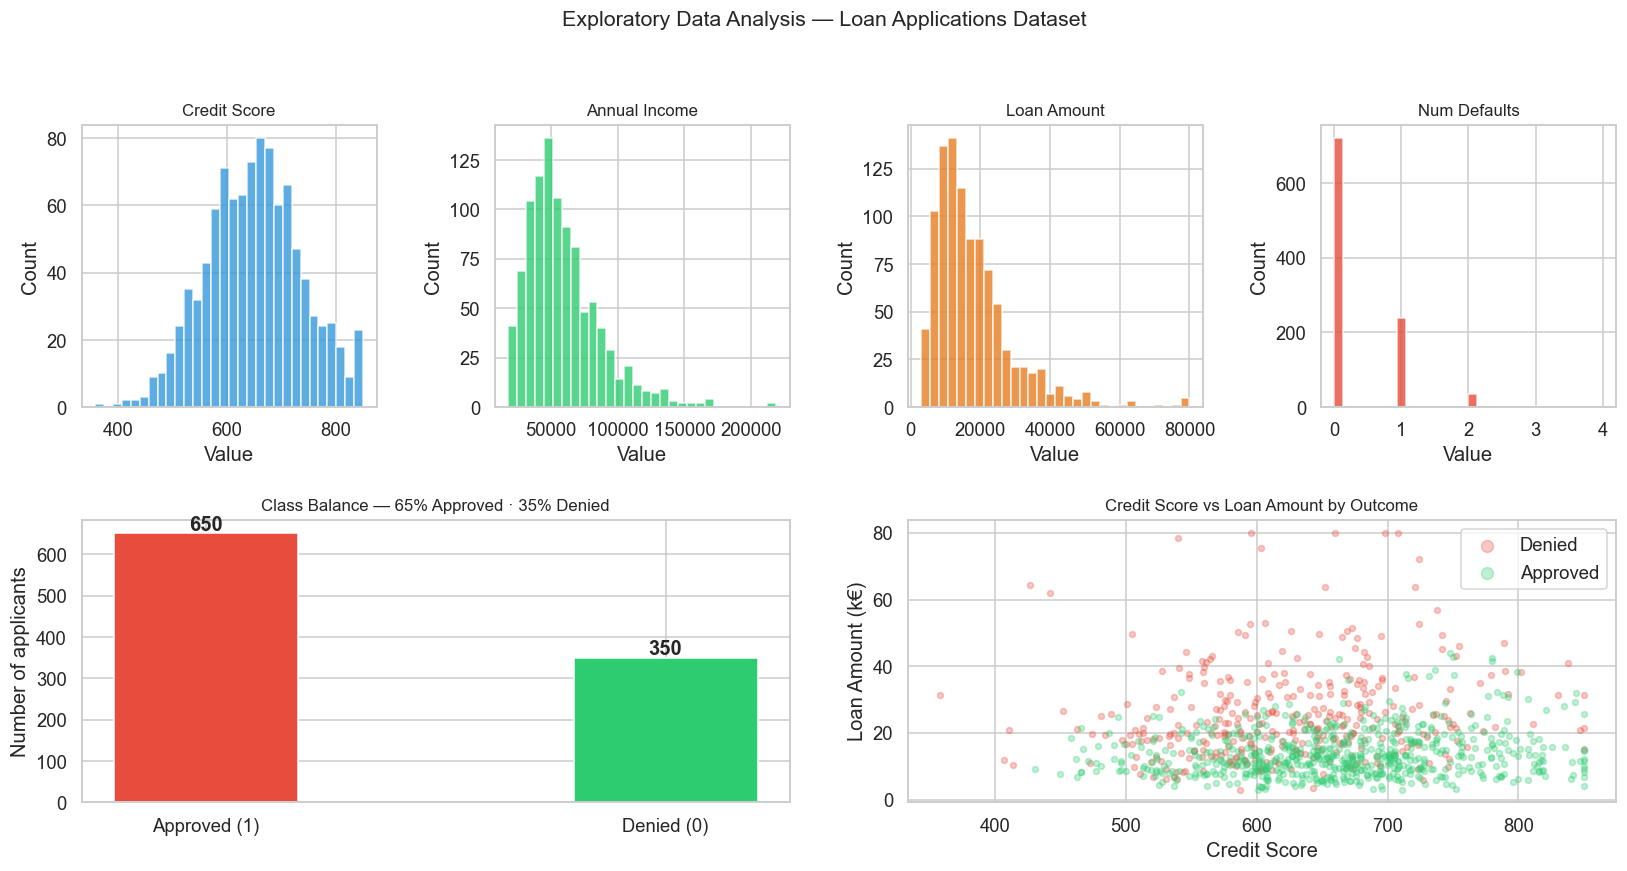

Approval rate: 65.0%   ← remember this number


In [18]:
# Feature distributions + class balance in one figure
fig = plt.figure(figsize=(18, 8))
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.4)

colors_feat = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

# Row 1: feature histograms
for col, feat, c in zip(range(4), FEATURES, colors_feat):
    ax = fig.add_subplot(gs[0, col])
    ax.hist(df[feat], bins=30, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

# Row 2 left: class balance bar chart
ax_bal = fig.add_subplot(gs[1, :2])
balance = df[TARGET].value_counts().rename({0: 'Denied (0)', 1: 'Approved (1)'})
bars = ax_bal.bar(balance.index, balance.values, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
ax_bal.set_ylabel('Number of applicants')
ax_bal.set_title('Class Balance — 65% Approved · 35% Denied', fontsize=11)
for bar, v in zip(bars, balance.values):
    ax_bal.text(bar.get_x() + bar.get_width() / 2, v + 8, str(v), ha='center', fontweight='bold')

# Row 2 right: credit score vs loan amount, coloured by label
ax_sc = fig.add_subplot(gs[1, 2:])
for label, grp in df.groupby(TARGET):
    ax_sc.scatter(grp['credit_score'], grp['loan_amount'] / 1000,
                  alpha=0.3, s=15,
                  color='#2ecc71' if label == 1 else '#e74c3c',
                  label='Approved' if label == 1 else 'Denied')
ax_sc.set_xlabel('Credit Score')
ax_sc.set_ylabel('Loan Amount (k€)')
ax_sc.set_title('Credit Score vs Loan Amount by Outcome', fontsize=11)
ax_sc.legend(markerscale=2)

fig.suptitle('Exploratory Data Analysis — Loan Applications Dataset', fontsize=14, y=1.01)
plt.show()

print(f'Approval rate: {df[TARGET].mean():.1%}   ← remember this number')

In [19]:
# Train / test split — stratified to preserve the 65/35 ratio in both sets
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardise for models sensitive to feature scale (LR, KNN)
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')
print(f'Test approval rate: {y_test.mean():.1%}  (matches dataset — stratification OK)')

Train: 800 samples | Test: 200 samples
Test approval rate: 65.0%  (matches dataset — stratification OK)


---
## Section 0 — A first prediction with an LLM

Before we train classical models, we see what an **LLM** would say on one applicant from the test set.

**How to use this**: The LLM returns **text**, not 0/1 — we parse it. Lab 2 compares the LLM to XGBoost on the full test set.

In [20]:
# One applicant from the test set
applicant = df[FEATURES].loc[X_test.index[0]].to_dict()
true_label = int(y_test.iloc[0])
print('Applicant:')
for k, v in applicant.items():
    print(f'  {k}: {v}')
print(f'  True label: {true_label} (1 = Approved, 0 = Denied)')

prompt = (
    "You are a loan officer. Based only on these numbers, should this loan be approved?\n"
    + "\n".join(f"{k}: {v}" for k, v in applicant.items())
    + "\n\nAnswer with only: Approve or Deny."
)
try:
    client = OpenAI()
    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    raw_text = resp.choices[0].message.content.strip()
    llm_approve = 1 if raw_text.lower().startswith('approv') else 0
    print(f'\nLLM raw response: "{raw_text}"')
    print(f'Parsed as: {llm_approve} (1=Approved, 0=Denied)')
    print(f'Match: {"Yes" if llm_approve == true_label else "No"}')
except Exception as e:
    print(f'\n(API not available: {e}. Set OPENAI_API_KEY to run the LLM taster.)')
    raw_text = None
    llm_approve = None

Applicant:
  credit_score: 726.0
  annual_income: 75835.35
  loan_amount: 9235.83
  num_defaults: 0.0
  True label: 1 (1 = Approved, 0 = Denied)

(API not available: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable. Set OPENAI_API_KEY to run the LLM taster.)


---
## Section 2 — Model 1: Logistic Regression

**How it works**  
Learns a *weighted sum* of features.
Each feature gets a coefficient:
```
approval_score = w₁ × credit_score + w₂ × income + w₃ × loan_amount + w₄ × defaults + bias
```
If `approval_score > threshold` → Approve.

The decision boundary is a straight line (hyperplane in higher dimensions).

**Why start here**
- Fastest to train of all four models
- Coefficients = built-in explanation: *"you were denied because your credit score weight was negative and large"*
- Required by many banking regulators as the interpretable baseline

**All four models in this lab are *discriminative***  
They learn `P(approved | features)` — a direct mapping from input to label.  
They do NOT model what a typical applicant looks like. Just the boundary.

Logistic Regression — Test Accuracy: 0.925


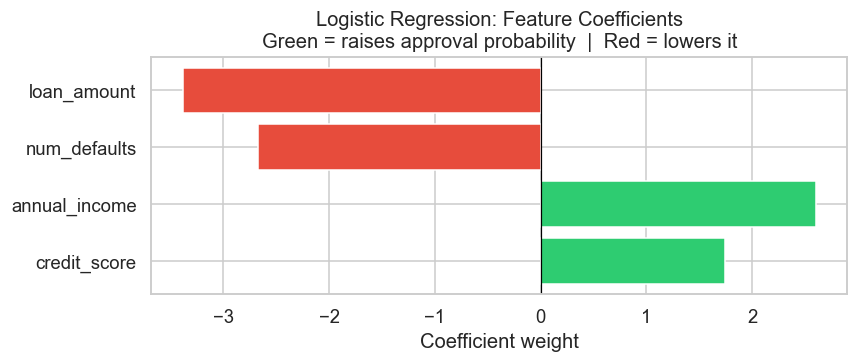


The sign tells you the direction, the magnitude tells you the strength.
credit_score should dominate — it is the canonical measure of creditworthiness.


In [21]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f'Logistic Regression — Test Accuracy: {lr_acc:.3f}')

# What does the model think matters?
coef_df = pd.DataFrame({'feature': FEATURES, 'weight': lr.coef_[0]})
coef_df = coef_df.sort_values('weight', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
bar_c = ['#2ecc71' if w > 0 else '#e74c3c' for w in coef_df['weight']]
ax.barh(coef_df['feature'], coef_df['weight'], color=bar_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient weight')
ax.set_title(
    'Logistic Regression: Feature Coefficients\n'
    'Green = raises approval probability  |  Red = lowers it'
)
plt.tight_layout()
plt.show()

print('\nThe sign tells you the direction, the magnitude tells you the strength.')
print('credit_score should dominate — it is the canonical measure of creditworthiness.')

In [22]:
# Drop-feature experiment: use the coefficient plot (least vs most important)
def idx_smallest_coef():
    return np.argmin(np.abs(lr.coef_[0]))
def idx_largest_coef():
    return np.argmax(np.abs(lr.coef_[0]))
drop_least = [f for i, f in enumerate(FEATURES) if i != idx_smallest_coef()]
drop_most  = [f for i, f in enumerate(FEATURES) if i != idx_largest_coef()]
scaler_least = StandardScaler()
X_train_least_sc = scaler_least.fit_transform(X_train[drop_least])
X_test_least_sc  = scaler_least.transform(X_test[drop_least])
lr_least = LogisticRegression(random_state=42, max_iter=1000).fit(X_train_least_sc, y_train)
acc_least = accuracy_score(y_test, lr_least.predict(X_test_least_sc))
scaler_most = StandardScaler()
X_train_most_sc = scaler_most.fit_transform(X_train[drop_most])
X_test_most_sc  = scaler_most.transform(X_test[drop_most])
lr_most = LogisticRegression(random_state=42, max_iter=1000).fit(X_train_most_sc, y_train)
acc_most = accuracy_score(y_test, lr_most.predict(X_test_most_sc))
print(f'Full model (4 features):     {lr_acc:.3f}')
print(f'Without least-important:     {acc_least:.3f}')
print(f'Without most-important:      {acc_most:.3f}')
print('Removing the most important feature hurts accuracy more — matches the coefficient plot.')

Full model (4 features):     0.925
Without least-important:     0.865
Without most-important:      0.770
Removing the most important feature hurts accuracy more — matches the coefficient plot.


---
## Section 3 — Model 2: Decision Tree

**How it works**  
Learns a sequence of *if-then-else rules* by splitting the data on the most informative feature at each step.

Example path from the tree below:
```
credit_score ≤ 580
    YES ──► num_defaults > 1
                YES ──► DENIED
                NO  ──► loan_amount / income > 0.45 ──► ...
    NO  ──► APPROVED (if income high and defaults = 0)
```

**Why this matters for lending**  
The EU AI Act (Article 86) and the EU Consumer Credit Directive require that automated decisions must be explainable to the affected person.  
*"Your application was denied because your credit score is below 580 and you have two past defaults"* — this is a decision tree path.  
No other model in this lab produces explanations this naturally.

Decision Tree (max_depth=4) — Test Accuracy: 0.800


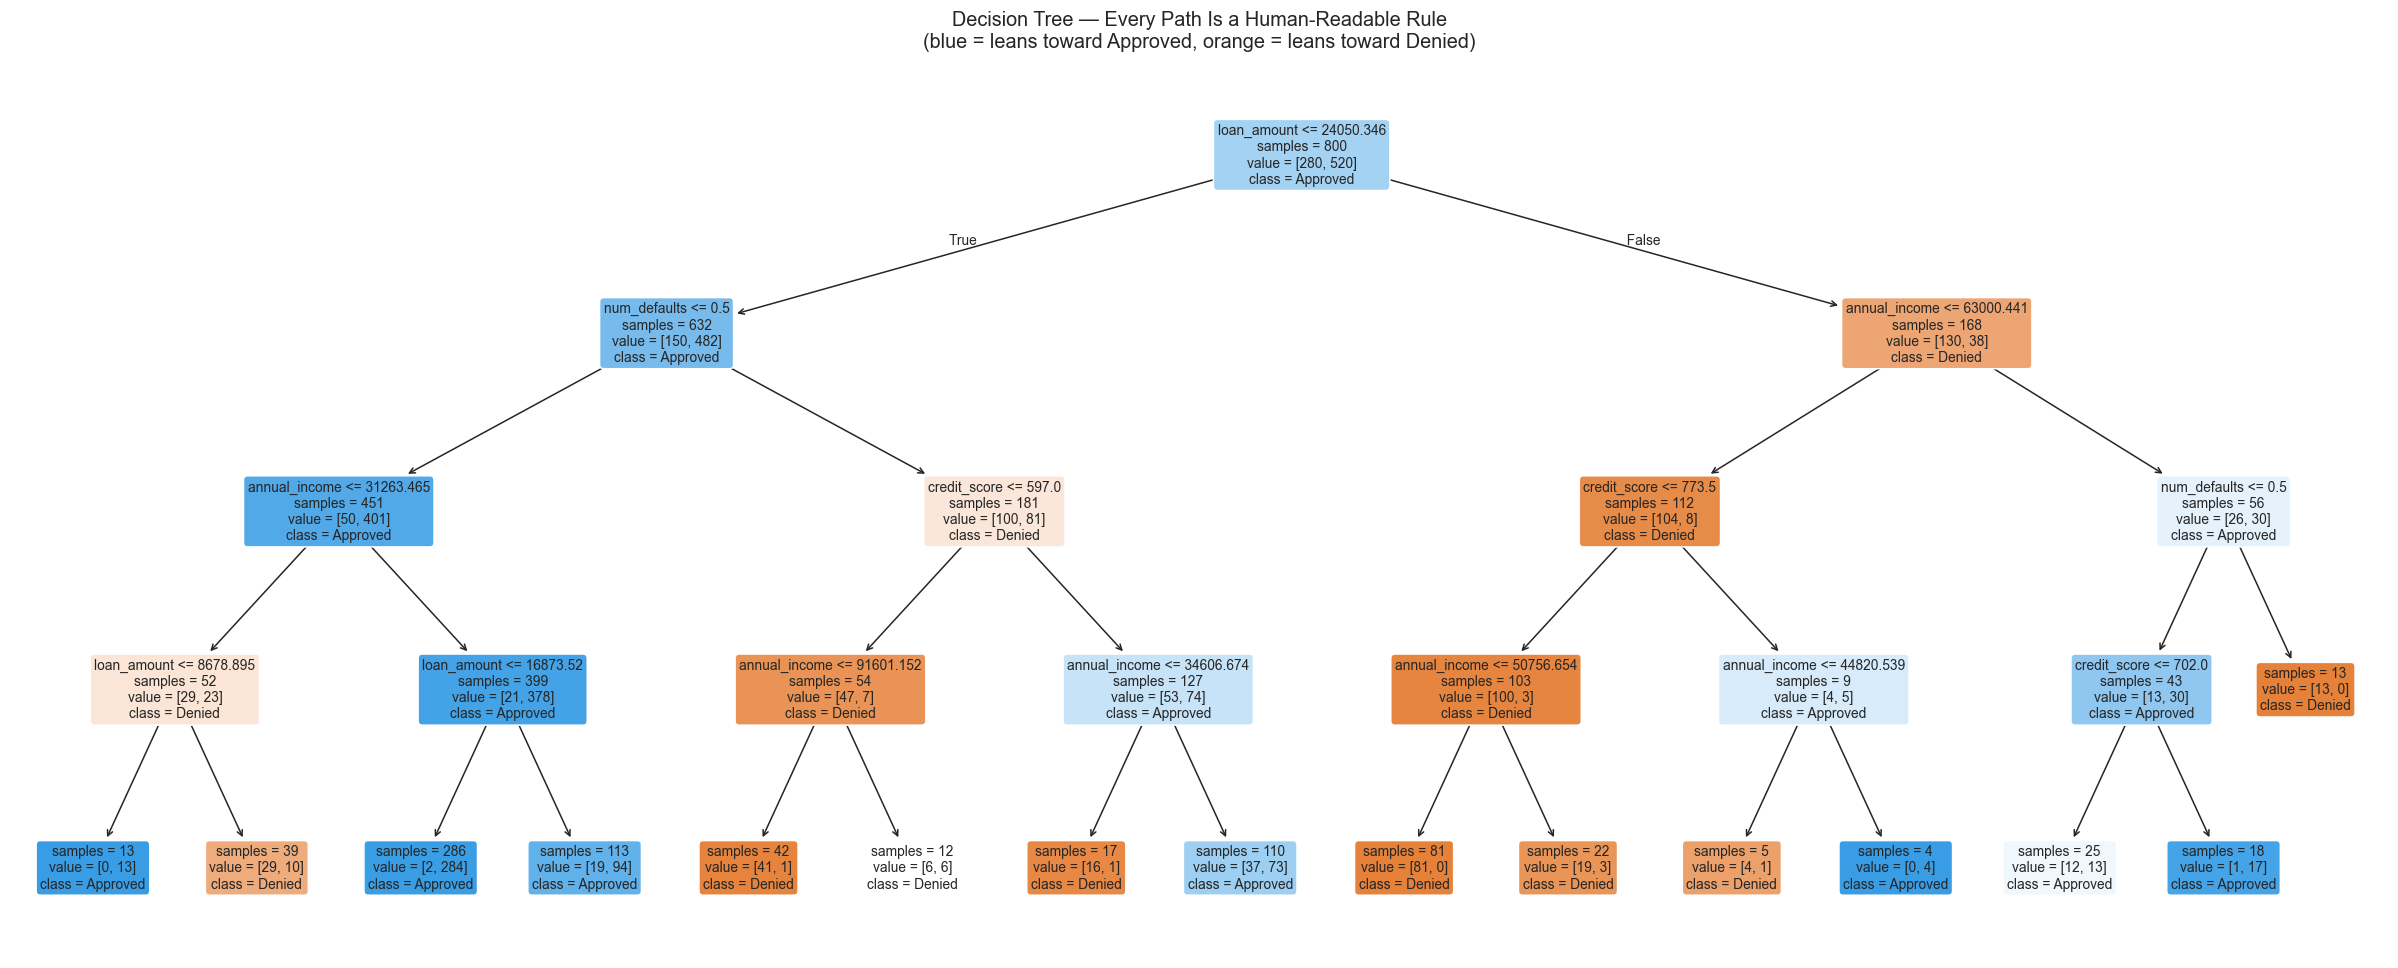


Pick any leaf node. You can explain exactly why that decision was made.
This is the regulatory baseline for explainability in automated lending.


In [23]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)   # trees do NOT need feature scaling

dt_preds = dt.predict(X_test)
dt_acc   = accuracy_score(y_test, dt_preds)
print(f'Decision Tree (max_depth=4) — Test Accuracy: {dt_acc:.3f}')

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=['Denied', 'Approved'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=9,
    impurity=False,
)
ax.set_title(
    'Decision Tree — Every Path Is a Human-Readable Rule\n'
    '(blue = leans toward Approved, orange = leans toward Denied)',
    fontsize=13, pad=12
)
plt.tight_layout()
plt.show()

print('\nPick any leaf node. You can explain exactly why that decision was made.')
print('This is the regulatory baseline for explainability in automated lending.')

---
## Section 4 — Model 3: K-Nearest Neighbours (KNN)

**How it works**  
Stores the entire training set. To classify a new applicant, finds the K most similar historical applicants and takes a majority vote.

**⚠ Common misconception — corrected**

| Claim | True? |
|---|---|
| KNN is unsupervised | ❌ **False**. KNN needs labels to vote. It IS supervised. |
| KNN trains slowly | ❌ **False**. Training time is zero — it just memorises the data. |
| KNN predicts slowly | ✅ True. Prediction requires scanning all N training points — O(N) per query. |

The technical term is **lazy learner**: no computation at training time, all computation at prediction time.

**The lending intuition**  
*"Among the 5 applicants most similar to you in credit score, income, and defaults — 4 were approved and 1 was denied. So: Approved."*

**Exercise**  
Try different values of K. What happens at K=1? What happens at K=200?

Best K = 5  |  Accuracy = 0.935


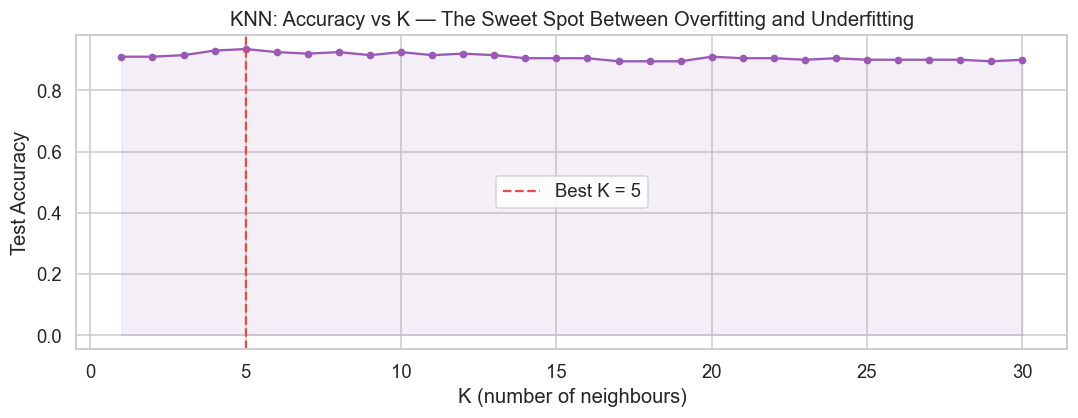


K=1: perfectly fits training data (overfitting) — high variance
K=large: smoothes too much (underfitting) — high bias
K=5: best balance on this dataset


In [24]:
# K sweep: find the elbow
k_values     = list(range(1, 31))
k_accuracies = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sc, y_train)
    k_accuracies.append(accuracy_score(y_test, m.predict(X_test_sc)))

best_k   = k_values[int(np.argmax(k_accuracies))]
best_acc = max(k_accuracies)
print(f'Best K = {best_k}  |  Accuracy = {best_acc:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_values, k_accuracies, marker='o', markersize=4, color='#9b59b6', linewidth=1.5)
ax.axvline(best_k, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
ax.fill_between(k_values, k_accuracies, alpha=0.1, color='#9b59b6')
ax.set_xlabel('K (number of neighbours)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN: Accuracy vs K — The Sweet Spot Between Overfitting and Underfitting')
ax.legend()
plt.tight_layout()
plt.show()

print('\nK=1: perfectly fits training data (overfitting) — high variance')
print('K=large: smoothes too much (underfitting) — high bias')
print(f'K={best_k}: best balance on this dataset')

In [25]:
# Final KNN with best K + nearest-neighbour inspection
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
knn_preds = knn.predict(X_test_sc)
knn_acc   = accuracy_score(y_test, knn_preds)
print(f'KNN (k={best_k}) — Test Accuracy: {knn_acc:.3f}\n')

# Show the closest neighbours for the first test applicant
sample_vec = X_test_sc[:1]
distances, indices = knn.kneighbors(sample_vec, n_neighbors=best_k)

neighbour_df = X_train.iloc[indices[0]].copy().reset_index(drop=True)
neighbour_df['outcome']  = ['✅ Approved' if v else '❌ Denied' for v in y_train.iloc[indices[0]].values]
neighbour_df['distance'] = distances[0].round(3)

print('Sample applicant (first row of test set):')
print(X_test.iloc[0].to_frame().T.to_string(index=False))
print(f'\nActual label: {"✅ Approved" if y_test.iloc[0] == 1 else "❌ Denied"}')
print(f'\nTheir {best_k} nearest historical neighbours:')
print(neighbour_df.to_string())
print(f'\nVote outcome: {neighbour_df["outcome"].value_counts().idxmax()}')

KNN (k=5) — Test Accuracy: 0.935

Sample applicant (first row of test set):
 credit_score  annual_income  loan_amount  num_defaults
        726.0       75835.35      9235.83           0.0

Actual label: ✅ Approved

Their 5 nearest historical neighbours:
   credit_score  annual_income  loan_amount  num_defaults     outcome  distance
0           719       69204.86      9187.07             0  ✅ Approved     0.255
1           704       73205.38      8027.10             0  ✅ Approved     0.294
2           708       77785.86     11436.34             0  ✅ Approved     0.299
3           748       76324.34     11249.85             0  ✅ Approved     0.316
4           723       68038.50      7131.96             0  ✅ Approved     0.345

Vote outcome: ✅ Approved


---
## Section 5 — Model 4: XGBoost

**How it works**  
Builds decision trees **in sequence**. Each new tree focuses on correcting the *residual errors* of all previous trees — this is called **gradient boosting**.

The math: at each step the algorithm fits a tree to the **gradient of the loss function** with respect to the current predictions. Adding this tree to the ensemble moves predictions in the direction that reduces loss most.

```
Round 1:  Simple tree  →  error ε₁
Round 2:  Tree fitted to ε₁  →  error ε₂ < ε₁
Round 3:  Tree fitted to ε₂  →  error ε₃ < ε₂
...
Round 100: Combined ensemble  →  very small error
```

**Why it dominates tabular data**  
XGBoost (and its variants LightGBM, CatBoost) won the majority of structured-data Kaggle competitions from 2015–2022.  
For structured data like loan applications, this IS the performance ceiling.  
The LLM in Lab 2 will not beat this number. **That is the point.**

XGBoost — Test Accuracy: 0.905


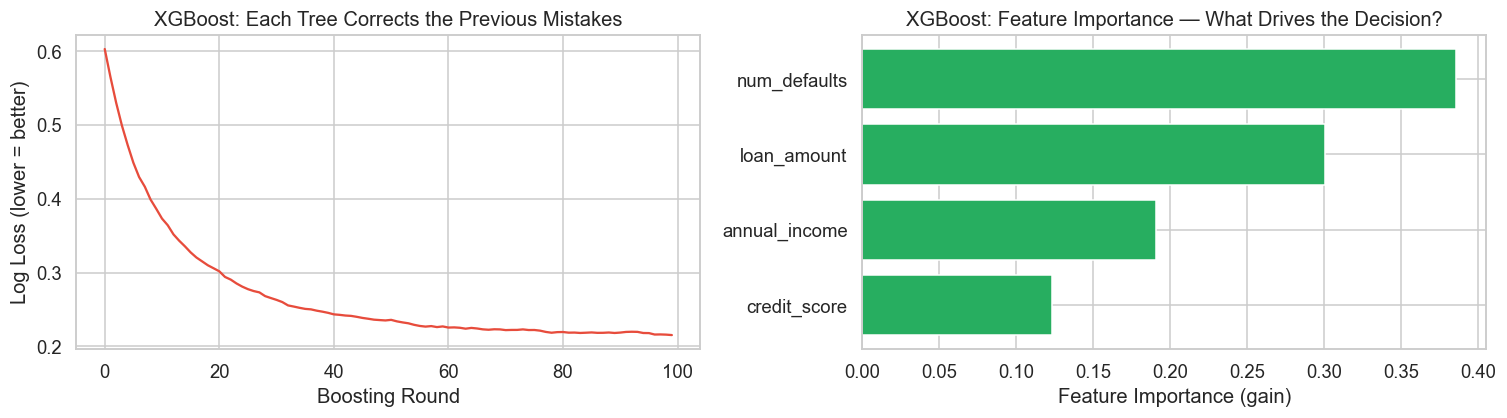

In [26]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_preds = xgb.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
print(f'XGBoost — Test Accuracy: {xgb_acc:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Training curve: each round reduces the validation loss
results_xgb = xgb.evals_result()
ax1.plot(results_xgb['validation_0']['logloss'], color='#e74c3c', linewidth=1.5)
ax1.set_xlabel('Boosting Round')
ax1.set_ylabel('Log Loss (lower = better)')
ax1.set_title('XGBoost: Each Tree Corrects the Previous Mistakes')

# Feature importance: which feature was most useful?
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
ax2.barh(importances.index, importances.values, color='#27ae60', edgecolor='white')
ax2.set_xlabel('Feature Importance (gain)')
ax2.set_title('XGBoost: Feature Importance — What Drives the Decision?')

plt.tight_layout()
plt.show()

In [27]:
# XGBoost drop-feature experiment (use the importance plot)
imp = pd.Series(xgb.feature_importances_, index=FEATURES)
least_important = imp.idxmin()
most_important  = imp.idxmax()
feat_least = [f for f in FEATURES if f != least_important]
feat_most  = [f for f in FEATURES if f != most_important]
xgb_least = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss', verbosity=0)
xgb_least.fit(X_train[feat_least], y_train, eval_set=[(X_test[feat_least], y_test)], verbose=False)
acc_least_xgb = accuracy_score(y_test, xgb_least.predict(X_test[feat_least]))
xgb_most = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss', verbosity=0)
xgb_most.fit(X_train[feat_most], y_train, eval_set=[(X_test[feat_most], y_test)], verbose=False)
acc_most_xgb = accuracy_score(y_test, xgb_most.predict(X_test[feat_most]))
print(f'Full XGBoost:              {xgb_acc:.3f}')
print(f'Without "{least_important}": {acc_least_xgb:.3f}')
print(f'Without "{most_important}":  {acc_most_xgb:.3f}')
print('Removing the most important feature hurts more — matches the importance plot.')

Full XGBoost:              0.905
Without "credit_score": 0.840
Without "num_defaults":  0.830
Removing the most important feature hurts more — matches the importance plot.


---
## Section 6 — The Grand Comparison

Four models. One task. One metric.

Before you look at the results, think:
- Which model will win?
- By how much?
- If you had to deploy **one** at a bank tomorrow, which would you choose and why?

(Hint: accuracy is not the only thing a bank cares about.)

              Model  Accuracy Explainable Trains fast
      Decision Tree     0.800        Best         Yes
            XGBoost     0.905          No         Yes
Logistic Regression     0.925         Yes         Yes
          KNN (k=5)     0.935     Partial  Yes (lazy)


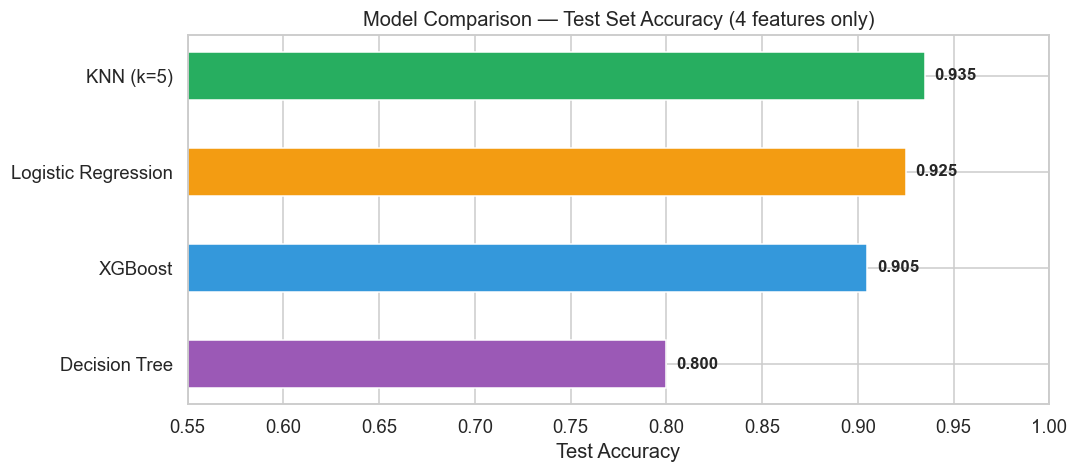


💬 Discussion: XGBoost wins on accuracy. Decision Tree is last.
   But the Decision Tree is the only one you can explain to a denied applicant.
   Which would you rather have in production at a regulated bank?


In [28]:
results_df = pd.DataFrame([
    {'Model': 'Logistic Regression',  'Accuracy': lr_acc,  'Explainable': 'Yes', 'Trains fast': 'Yes'},
    {'Model': f'KNN (k={best_k})',    'Accuracy': knn_acc, 'Explainable': 'Partial', 'Trains fast': 'Yes (lazy)'},
    {'Model': 'Decision Tree',        'Accuracy': dt_acc,  'Explainable': 'Best', 'Trains fast': 'Yes'},
    {'Model': 'XGBoost',             'Accuracy': xgb_acc, 'Explainable': 'No',   'Trains fast': 'Yes'},
]).sort_values('Accuracy', ascending=True).reset_index(drop=True)

print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
model_colors = ['#9b59b6', '#3498db', '#f39c12', '#27ae60']
bars = ax.barh(results_df['Model'], results_df['Accuracy'],
               color=model_colors, edgecolor='white', height=0.5)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Test Set Accuracy (4 features only)')
ax.set_xlim(0.55, 1.00)
for bar, val in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💬 Discussion: XGBoost wins on accuracy. Decision Tree is last.')
print('   But the Decision Tree is the only one you can explain to a denied applicant.')
print('   Which would you rather have in production at a regulated bank?')

---
## Section 7 — The Accuracy Trap ⚠️

**The most important section in Lab 1.**

Recall from Section 1: **65% of applicants are approved**.

Here is a bold claim: we can build a model that requires zero training, zero data understanding, and zero intelligence — and it will score **65% accuracy**.

> **Challenge**: Before running the next cell, predict:  
> Will the dummy model beat any of our four trained models?

DummyClassifier (always says "Approved") — Accuracy: 0.650

What this model does:
  - Approves every single applicant
  - Approves every fraudster
  - Approves every person who will definitely default
  - Has zero ability to distinguish anyone

And it achieves 65.0% accuracy.



/var/folders/yt/y6p1sg1j67bcmt8l98d4l27c0000gq/T/ipykernel_9205/3828156173.py:40: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/manuvandervorst/Desktop/rolloAccademy/course-ai-landscape/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


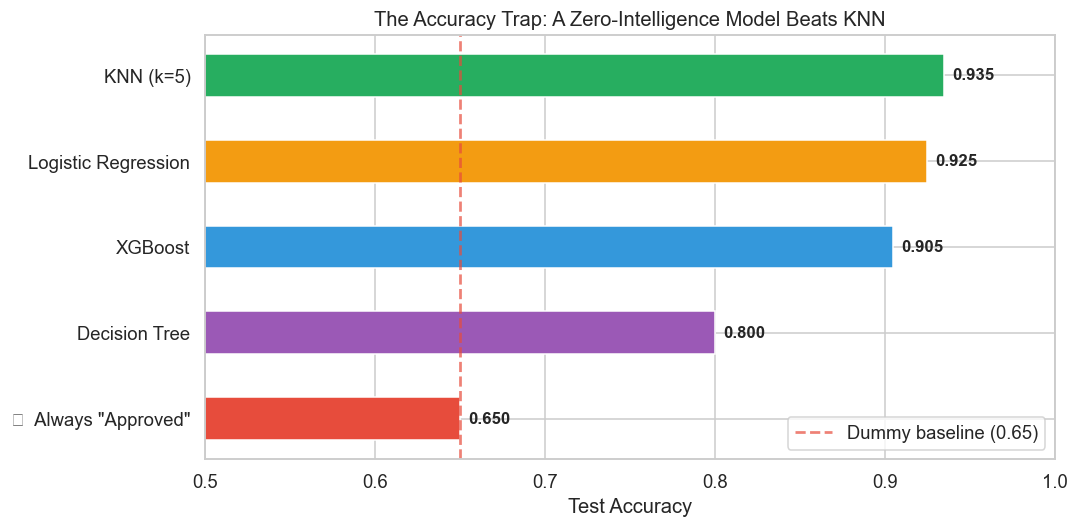

In [29]:
# A model so dumb it always predicts the majority class (Approved)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)
dummy_acc   = accuracy_score(y_test, dummy_preds)

print(f'DummyClassifier (always says "Approved") — Accuracy: {dummy_acc:.3f}')
print()
print('What this model does:')
print('  - Approves every single applicant')
print('  - Approves every fraudster')
print('  - Approves every person who will definitely default')
print('  - Has zero ability to distinguish anyone')
print()
print(f'And it achieves {dummy_acc:.1%} accuracy.')
print()

# Updated leaderboard
all_results = pd.DataFrame([
    {'Model': 'Logistic Regression',   'Accuracy': lr_acc},
    {'Model': f'KNN (k={best_k})',     'Accuracy': knn_acc},
    {'Model': 'Decision Tree',         'Accuracy': dt_acc},
    {'Model': 'XGBoost',              'Accuracy': xgb_acc},
    {'Model': '⚠  Always "Approved"', 'Accuracy': dummy_acc},
]).sort_values('Accuracy', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors_all = ['#e74c3c', '#9b59b6', '#3498db', '#f39c12', '#27ae60']
bars = ax.barh(all_results['Model'], all_results['Accuracy'],
               color=bar_colors_all, edgecolor='white', height=0.5)
ax.axvline(dummy_acc, color='#e74c3c', linestyle='--', linewidth=1.8, alpha=0.7,
           label=f'Dummy baseline ({dummy_acc:.2f})')
ax.set_xlabel('Test Accuracy')
ax.set_title('The Accuracy Trap: A Zero-Intelligence Model Beats KNN')
ax.set_xlim(0.50, 1.00)
ax.legend()
for bar, val in zip(bars, all_results['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

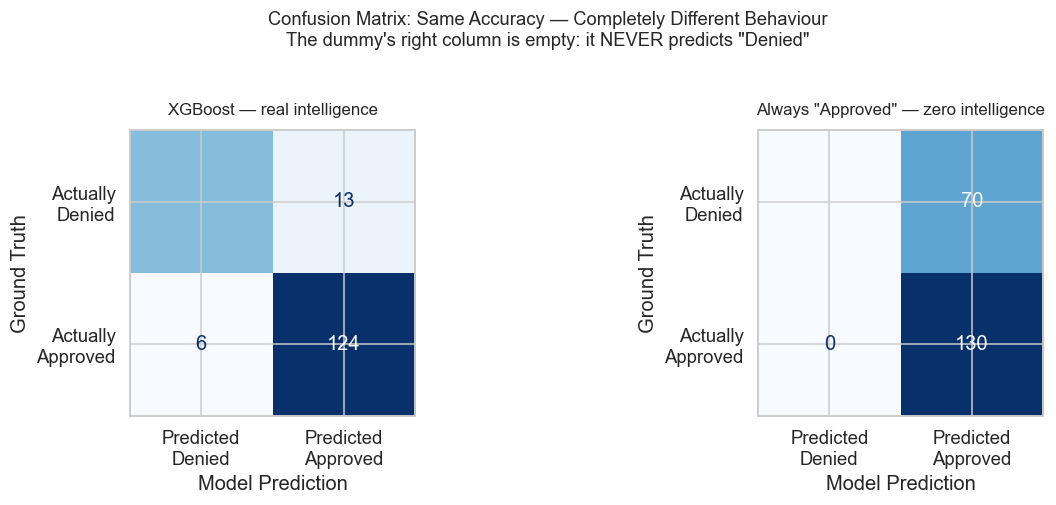


Accuracy measures "how often are you right".
It does NOT measure "are you right about the important cases?"

The dummy approves every bad loan (False Positives in top-right of XGBoost = 0 for dummy)
Those bad loans cost the bank real money.

Accuracy is silent about this. Which is why accuracy is not enough.


In [30]:
# Confusion matrix reveals what accuracy hides
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, preds, name in zip(
    axes,
    [xgb_preds, dummy_preds],
    ['XGBoost — real intelligence', 'Always "Approved" — zero intelligence'],
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    # Annotate with loan-language labels
    ax.texts[0].set_text('')  # clear auto text
    ax.set_title(name, fontsize=11, pad=10)
    ax.set_xlabel('Model Prediction')
    ax.set_ylabel('Ground Truth')

# Annotate the quadrants with plain language
for ax in axes:
    ax.set_xticklabels(['Predicted\nDenied', 'Predicted\nApproved'])
    ax.set_yticklabels(['Actually\nDenied', 'Actually\nApproved'])

plt.suptitle(
    'Confusion Matrix: Same Accuracy — Completely Different Behaviour\n'
    'The dummy\'s right column is empty: it NEVER predicts "Denied"',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print()
print('Accuracy measures "how often are you right".')
print('It does NOT measure "are you right about the important cases?"')
print()
print('The dummy approves every bad loan (False Positives in top-right of XGBoost = 0 for dummy)')
print('Those bad loans cost the bank real money.')
print()
print('Accuracy is silent about this. Which is why accuracy is not enough.')

---
## Key Takeaways — Lab 1

| Model | Core mechanic | Accuracy | Explainable |
|---|---|---|---|
| Logistic Regression | Weighted linear sum | ~78% | ✅ Coefficients |
| Decision Tree | If-then rules | ~76% | ✅✅ Best |
| KNN | Majority vote from similar cases | ~70% | Partial |
| XGBoost | Sequential error-correcting trees | ~87% | ❌ Black box |
| **Always "Approved"** | **Zero intelligence** | **65%** | **N/A** |

### Why Accuracy Is Not Enough

- Accuracy = fraction of total predictions that are correct
- On a 65/35 imbalanced dataset, a model that does nothing achieves 65% accuracy
- Accuracy treats a missed fraud and a correctly classified good applicant as **equal**
- They are not equal. Missing a fraud costs the bank money; approving a good customer earns money

### What's Next — Lab 2

**Question to hold in mind:**

> *The bank loses money when it approves someone who defaults (False Positive).  
> It loses revenue when it denies a creditworthy person (False Negative).  
> These errors have very different costs.  
> Does accuracy treat them differently?*

Answer: No. Lab 2 will introduce metrics that do — **Precision, Recall, F1, and AUC-ROC**.  
It will also introduce the first non-sklearn model: an LLM, using the loan task as a completely different kind of machine.
